In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, GRU, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
path = "/content/drive/MyDrive/Sensor_DL/final_data"

X_train = np.load(os.path.join(path, "X_train.npy"))
y_train = np.load(os.path.join(path, "y_train.npy"))

X_val = np.load(os.path.join(path, "X_val.npy"))
y_val = np.load(os.path.join(path, "y_val.npy"))

X_test = np.load(os.path.join(path, "X_test.npy"))
y_test = np.load(os.path.join(path, "y_test.npy"))

In [ ]:
y_train = y_train.astype(int) - 1
y_val   = y_val.astype(int) - 1
y_test  = y_test.astype(int) - 1

num_classes = len(np.unique(y_train))

In [ ]:
y_train = to_categorical(y_train, num_classes)
y_val   = to_categorical(y_val, num_classes)
y_test  = to_categorical(y_test, num_classes)

print("Train:", X_train.shape, y_train.shape)

Train: (24665, 50, 21) (24665, 12)


In [ ]:
print("Input shape for model:", X_train.shape[1], X_train.shape[2])

Input shape for model: 50 21


In [ ]:
model = Sequential()

# ---- CNN (preserve sequence) ----
model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(BatchNormalization())

model.add(Conv1D(
    filters=128,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(BatchNormalization())

# ---- GRU ----
model.add(GRU(128, return_sequences=False))

# ---- Dense ----
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,700 (573.05 KB)

 Trainable params: 146,316 (571.55 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Sensor_DL/cnn_gru_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/40
771/771 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4558 - loss: 1.5837
Epoch 1: val_accuracy improved from None to 0.81741, saving model to /content/drive/MyDrive/Sensor_DL/cnn_gru_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Sensor_DL/cnn_gru_best.keras
771/771 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6165 - loss: 1.1128 - val_accuracy: 0.8174 - val_loss: 0.5357
Epoch 2/40
770/771 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8168 - loss: 0.5262
Epoch 2: val_accuracy improved from 0.81741 to 0.87037, saving model to /content/drive/MyDrive/Sensor_DL/cnn_gru_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Sensor_DL/cnn_gru_best.keras
771/771 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8317 - loss: 0.4804 - val_accuracy: 0.8704 - val_loss: 0.3794
Epoch 3/40
769/771 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8803 - loss: 0.3423
Epoch 3: val_accuracy improved from 0.87037 to 0.89444, saving model to /content/dri

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")

214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9482 - loss: 0.1739

✅ Test Accuracy: 0.9482


214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


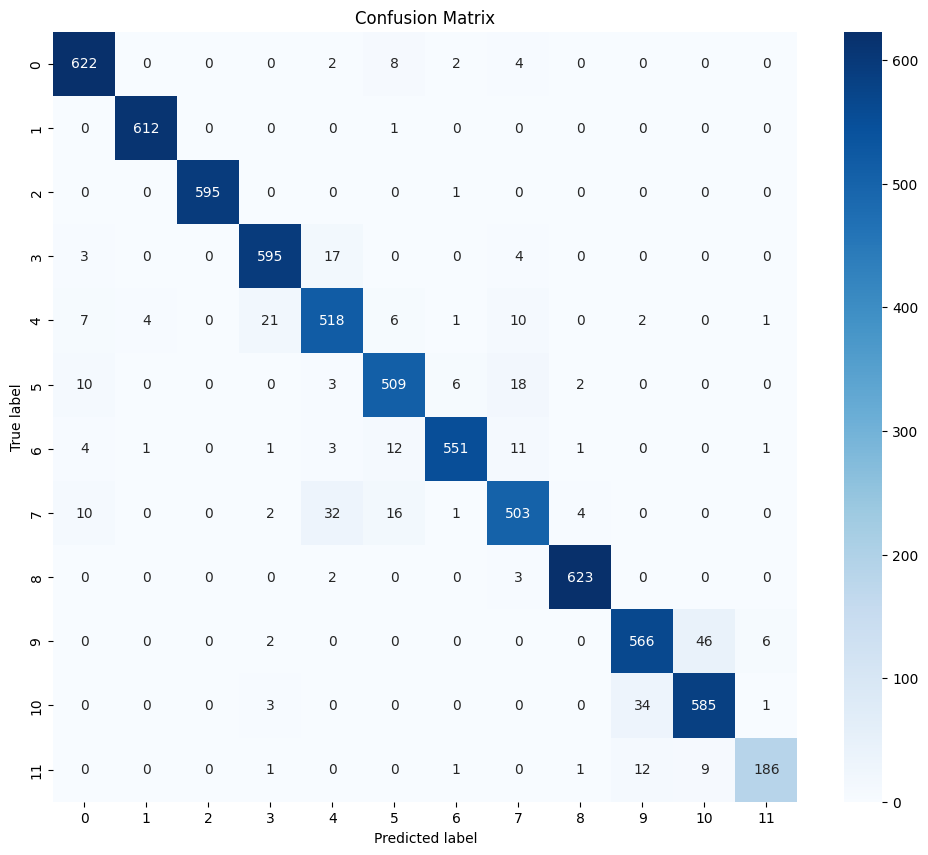

Confusion Matrix:
 [[622   0   0   0   2   8   2   4   0   0   0   0]
 [  0 612   0   0   0   1   0   0   0   0   0   0]
 [  0   0 595   0   0   0   1   0   0   0   0   0]
 [  3   0   0 595  17   0   0   4   0   0   0   0]
 [  7   4   0  21 518   6   1  10   0   2   0   1]
 [ 10   0   0   0   3 509   6  18   2   0   0   0]
 [  4   1   0   1   3  12 551  11   1   0   0   1]
 [ 10   0   0   2  32  16   1 503   4   0   0   0]
 [  0   0   0   0   2   0   0   3 623   0   0   0]
 [  0   0   0   2   0   0   0   0   0 566  46   6]
 [  0   0   0   3   0   0   0   0   0  34 585   1]
 [  0   0   0   1   0   0   1   0   1  12   9 186]]

Accuracy:  0.9482252860076269

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       638
           1       0.99      1.00      1.00       613
           2       1.00      1.00      1.00       596
           3       0.95      0.96      0.96       619
           4       0.90      0.91      0.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Get predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Convert y_test from one-hot encoding back to class labels
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Calculate and print additional metrics
print("\nAccuracy: ", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))